In [ ]:
# --- repo path setup (added during reorg) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


# Plaquette Instability Local-Motif Figures (stick, L, chiral)

This notebook assembles figure-ready outputs from:
- `instability_stick_shaped_analysis_tangent_warm.ipynb`
- `instability_l_shaped_analysis_tangent_warm.ipynb`
- `chiral_mixture_plaquette_instability_analysis_body_groups_chiralsep.ipynb`

using a single plotting scheme consistent with `stick_l_critical_lines.ipynb`.

The chiral analysis in this notebook uses:
- fixed blue fraction `phi_blue=0.25` (equivalently fixed red fraction `phi_red=0.25` for `rho_empty=0.5`),
- fixed vacancy fraction `rho_empty`,
- the plain full Hessian at each constrained optimum,
- the first six negative eigenmodes as the instability diagnostic,
- raw motif rankings for each mode.

## Generated figure files
- `fig_instability_lambda_scan_<regime>.[pdf|png]`
- `fig_motifs_stick_<regime>_mode[1-3].[pdf|png]`
- `fig_motifs_lshape_<regime>_mode[1-3].[pdf|png]`
- `fig_chiral_fixed_phi_blue025_alltemps.[pdf|png]`
- `fig_motifs_chiral_fixed_phi_blue025_<label>_mode[1-6].[pdf|png]`


In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import torch.autograd.functional as AF
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Ellipse
from matplotlib.ticker import AutoMinorLocator

from plaquette_by_species import (
    build_plaquettes_by_species,
    build_A_rows_from_plaq,
    residual_free_energy_simple,
    residual_free_energy_by_species,
    monomer_free_energy_general,
)

# PRL/APS-like style (aligned with stick_l_critical_lines.ipynb)
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.6,
    "lines.solid_capstyle": "round",
    "lines.dash_capstyle": "round",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "legend.frameon": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

DEVICE = "cpu"
DTYPE = torch.float64


In [2]:
# ---------- Optimization and Hessian helpers ----------

def _stack_constraints(A, phi, G=None):
    A = np.atleast_2d(A).astype(np.float64)
    rows = [A]
    rhs = [np.full(A.shape[0], phi, dtype=np.float64)]
    if G is not None:
        rows.append(np.asarray(G, dtype=np.float64))
        rhs.append(np.zeros(np.asarray(G).shape[0], dtype=np.float64))
    return np.vstack(rows), np.concatenate(rhs)


def constrained_softmax(z, C, d, tol=1e-10, max_newton=50, ridge=1e-12):
    m, _ = C.shape
    eta = torch.zeros(m, dtype=z.dtype, device=z.device, requires_grad=True)
    for _ in range(max_newton):
        logits = z + C.t().matmul(eta)
        rho = F.softmax(logits, dim=0)
        g = C.matmul(rho) - d
        if torch.linalg.norm(g) <= tol:
            break
        W = C * rho.unsqueeze(0)
        J = W.matmul(C.t()) - torch.outer(C.matmul(rho), C.matmul(rho))
        J = J + ridge * torch.eye(m, dtype=z.dtype, device=z.device)
        delta = torch.linalg.solve(J, -g)
        eta = eta + torch.clamp(delta, -50.0, 50.0)

    logits = z + C.t().matmul(eta)
    rho = F.softmax(logits, dim=0)
    res = torch.linalg.norm(C.matmul(rho) - d)
    return rho, eta, float(res.item())


def monomer_free_energy_from_plaquettes(
    phi,
    A,
    f_tilde_torch,
    G=None,
    steps=1200,
    lr=0.5,
    tol_res=1e-5,
    device=DEVICE,
    dtype=DTYPE,
    z0=None,
):
    C_np, d_np = _stack_constraints(A, phi, G)
    C = torch.tensor(C_np, dtype=dtype, device=device)
    d = torch.tensor(d_np, dtype=dtype, device=device)
    P = C.shape[1]

    if z0 is None:
        z = torch.zeros(P, dtype=dtype, device=device, requires_grad=True)
    else:
        z = z0.clone().detach().requires_grad_(True)

    opt = torch.optim.Adagrad([z], lr=lr)
    best = {"f": float("inf"), "rho": None, "res": float("inf"), "z": None}
    prev_f = None

    for _ in range(steps):
        rho, _, _ = constrained_softmax(z, C, d, tol=tol_res)
        f = f_tilde_torch(rho)

        opt.zero_grad()
        f.backward()
        grad_norm = float(z.grad.norm().item()) if z.grad is not None else np.nan
        opt.step()

        with torch.no_grad():
            rho2, _, res2 = constrained_softmax(z, C, d, tol=tol_res)
            f2 = float(f_tilde_torch(rho2).item())
            if (f2 < best["f"]) and (res2 <= best["res"] + 1e-12):
                best["f"] = f2
                best["rho"] = rho2.clone()
                best["res"] = res2
                best["z"] = z.clone()

        if prev_f is not None and abs(f2 - prev_f) <= tol_res:
            break
        prev_f = f2

        if np.isnan(grad_norm) or grad_norm <= tol_res:
            break

    rho_star = best["rho"]
    if rho_star is None:
        rho_star = constrained_softmax(z.detach(), C, d, tol=tol_res)[0].detach()

    return {
        "f_phi": float(f_tilde_torch(rho_star).item()),
        "rho": rho_star.detach().cpu().numpy(),
        "residual": float(torch.linalg.norm(C @ rho_star - d).item()),
        "C_np": C_np,
        "d_np": d_np,
        "z": best["z"] if best["z"] is not None else z.detach(),
    }


def projected_hessian_spectrum(rho_np, f_tilde, vectorize_hessian=True):
    rho = torch.tensor(rho_np, dtype=DTYPE, device=DEVICE, requires_grad=True)

    H = AF.hessian(lambda r: f_tilde(r), rho, create_graph=False, vectorize=vectorize_hessian)
    H_np = H.detach().cpu().numpy()
    H_np = 0.5 * (H_np + H_np.T)

    # Plain (unconstrained) Hessian spectrum in the full rho-space.
    evals, evecs_full = np.linalg.eigh(H_np)
    return evals, evecs_full, H_np, None


def mode_chiral_projection(evec, A1, A2):
    ch = np.asarray(A1, float) - np.asarray(A2, float)
    v = np.asarray(evec, float)
    raw = float(ch @ v)
    den = float(np.linalg.norm(ch) * np.linalg.norm(v))
    norm = raw / den if den > 1e-14 else 0.0
    return raw, norm
def normalized_overlap(evec, channel):
    v = np.asarray(evec, dtype=float).ravel()
    ch = np.asarray(channel, dtype=float).ravel()
    den = float(np.linalg.norm(v) * np.linalg.norm(ch))
    if den <= 1e-14:
        return 0.0
    return float(np.dot(v, ch) / den)


def top_unstable_mode_ids(evals, max_modes=3, tol=0.0):
    evals = np.asarray(evals, dtype=float)
    neg = np.where(evals < tol)[0]
    if neg.size == 0:
        return []
    order = neg[np.argsort(evals[neg])]
    return order[:max_modes].tolist()


def describe_mode_components(mode_vec, plaq_configs, top_n=4):
    v = np.asarray(mode_vec, dtype=float).ravel()
    score = np.abs(v)
    order = np.argsort(-score)[: min(int(top_n), v.size)]
    rows = []
    for j in order:
        rows.append({
            'index': int(j),
            'cfg': tuple(int(x) for x in plaq_configs[j]),
            'value': float(v[j]),
            'score': float(score[j]),
        })
    return rows



In [51]:
# ---------- Drawing helpers: ellipse patches for stick/L ----------

def draw_particle_ellipse_patches(
    ax,
    cx,
    cy,
    n_e_s_w,
    *,
    r=0.36,
    facecolor="#e8e8e8",
    patch_color="navy",
    edgecolor="0.25",
    lw=0.55,
    vacancy_patch_id=2,
):
    """Draw one particle as a circle plus clipped blue elliptical patches (N,E,S,W).

    If all four entries are `vacancy_patch_id` (default 2), draw only the circle.
    """
    flags = np.asarray(n_e_s_w, dtype=float).ravel()
    if flags.size != 4:
        raise ValueError("Expected [N,E,S,W] patch vector")

    body = Circle((cx, cy), r, facecolor=facecolor, edgecolor=edgecolor, linewidth=lw, zorder=2)
    ax.add_patch(body)

    is_vacancy = np.allclose(flags, float(vacancy_patch_id))
    if is_vacancy:
        return

    has = [(abs(flags[i]) > 1e-12) and (int(round(flags[i])) != vacancy_patch_id) for i in range(4)]

    # Parameters matched to stick_l_critical_lines inset style, then clipped to the circle body.
    dx = 0.72 * r
    ew_side, eh_side = 0.70 * r, 1.05 * r
    ew_tb, eh_tb = 1.05 * r, 0.70 * r

    if has[0]:
        e = Ellipse((cx, cy + dx), ew_tb, eh_tb, angle=0.0, linewidth=0.0, fill=True, color=patch_color, zorder=3)
        e.set_clip_path(body)
        ax.add_patch(e)
    if has[1]:
        e = Ellipse((cx + dx, cy), ew_side, eh_side, angle=0.0, linewidth=0.0, fill=True, color=patch_color, zorder=3)
        e.set_clip_path(body)
        ax.add_patch(e)
    if has[2]:
        e = Ellipse((cx, cy - dx), ew_tb, eh_tb, angle=0.0, linewidth=0.0, fill=True, color=patch_color, zorder=3)
        e.set_clip_path(body)
        ax.add_patch(e)
    if has[3]:
        e = Ellipse((cx - dx, cy), ew_side, eh_side, angle=0.0, linewidth=0.0, fill=True, color=patch_color, zorder=3)
        e.set_clip_path(body)
        ax.add_patch(e)


def draw_plaquette_tabbed(
    ax,
    cfg,
    patches_species,
    species_facecolors,
    patch_tab_color="navy",
    vacancy_patch_id=2,
):
    patches_species = np.asarray(patches_species, dtype=float)
    sUL, sUR, sBL, sBR = map(int, cfg)

    ax.set_xlim(0.12, 1.88)
    ax.set_ylim(0.12, 1.88)
    ax.set_aspect("equal")
    ax.axis("off")

    # Larger and closer particles
    corners = [(0.57, 1.43, sUL), (1.43, 1.43, sUR), (0.57, 0.57, sBL), (1.43, 0.57, sBR)]
    for cx, cy, sp in corners:
        vec = patches_species[sp] if (0 <= sp < patches_species.shape[0]) else np.zeros(4)
        fc = species_facecolors.get(sp, "#e8e8e8")
        draw_particle_ellipse_patches(
            ax,
            cx,
            cy,
            vec,
            facecolor=fc,
            patch_color=patch_tab_color,
            vacancy_patch_id=vacancy_patch_id,
        )


# ---------- Drawing helpers: chiral ABCD patches ----------

PATCH_ABCD_COLORS = {
    1: "#ff4a4a",  # A
    2: "#4b5bff",  # B
    3: "#45d84a",  # C
    4: "#8b5a5a",  # D
}


def chiral_handedness_body_color(species_index, vacancy_species_idx=8):
    """Body color by handedness/isomer block."""
    s = int(species_index)
    if s == int(vacancy_species_idx):
        return "#d9d9d9"
    if 0 <= s <= 3:
        return "#f6c2c2"  # one handedness
    if 4 <= s <= 7:
        return "#c8d5ff"  # opposite handedness
    return "#d9d9d9"


def draw_particle_chiral_abcd(
    ax,
    center,
    species_index,
    patches,
    *,
    r=0.40,
    facecolor=None,
    edgecolor="0.15",
    lw=0.6,
    vacancy_species_idx=8,
    vacancy_patch_id=5,
):
    x, y = center

    species_index = int(species_index)
    if facecolor is None:
        facecolor = chiral_handedness_body_color(species_index, vacancy_species_idx=vacancy_species_idx)

    body = Circle((x, y), r, facecolor=facecolor, edgecolor=edgecolor, linewidth=lw, zorder=2)
    ax.add_patch(body)

    dirs = np.asarray(patches[species_index], dtype=int)

    # Vacancy/empty species: plain circle only
    if (species_index == int(vacancy_species_idx)) or np.all(dirs == int(vacancy_patch_id)):
        return

    dx = 0.72 * r
    ew_side, eh_side = 0.70 * r, 1.05 * r
    ew_tb, eh_tb = 1.05 * r, 0.70 * r

    # N, E, S, W
    centers = [
        (x, y + dx, ew_tb, eh_tb),
        (x + dx, y, ew_side, eh_side),
        (x, y - dx, ew_tb, eh_tb),
        (x - dx, y, ew_side, eh_side),
    ]

    for pid, (cx, cy, w, h) in zip(dirs.tolist(), centers):
        if pid in PATCH_ABCD_COLORS:
            e = Ellipse((cx, cy), w, h, angle=0.0, linewidth=0.0, fill=True, color=PATCH_ABCD_COLORS[int(pid)], zorder=3)
            e.set_clip_path(body)
            ax.add_patch(e)


def draw_plaquette_chiral(ax, cfg, patches, vacancy_species_idx=8):
    sUL, sUR, sBL, sBR = [int(x) for x in cfg]

    # Larger and closer particles
    draw_particle_chiral_abcd(ax, (0.57, 1.43), sUL, patches, vacancy_species_idx=vacancy_species_idx)
    draw_particle_chiral_abcd(ax, (1.43, 1.43), sUR, patches, vacancy_species_idx=vacancy_species_idx)
    draw_particle_chiral_abcd(ax, (0.57, 0.57), sBL, patches, vacancy_species_idx=vacancy_species_idx)
    draw_particle_chiral_abcd(ax, (1.43, 0.57), sBR, patches, vacancy_species_idx=vacancy_species_idx)

    ax.set_xlim(0.12, 1.88)
    ax.set_ylim(0.12, 1.88)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def plot_mode_panel(
    plaq_configs,
    plaq_class_members,
    patches,
    mode_vec,
    *,
    title,
    n_show,
    drawer,
    drawer_kwargs,
    figsize=(5.4, 2.55),
    bar_top_k=14,
    bar_tail_thresh=0.08,
):
    v = np.asarray(mode_vec, dtype=float).ravel()
    P = len(v)

    vnorm = float(np.linalg.norm(v)) if P > 0 else 0.0
    v_disp = v / (vnorm + 1e-30)
    order = np.argsort(-np.abs(v_disp))

    def _split_by_sign(indices):
        pos = [int(j) for j in indices if v_disp[int(j)] > 0.0]
        neg = [int(j) for j in indices if v_disp[int(j)] < 0.0]
        zero = [int(j) for j in indices if abs(v_disp[int(j)]) <= 1e-15]
        return pos, neg, zero

    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [1.0, 1.08]},
        constrained_layout=False,
    )
    fig.subplots_adjust(left=0.09, right=0.995, bottom=0.165, top=0.985, wspace=0.035)
    axb, axg = axes

    abs_sorted = np.abs(v_disp[order])
    sig_idx = np.where(abs_sorted >= float(bar_tail_thresh))[0]
    kbar_sig = int(sig_idx[-1] + 1) if sig_idx.size else int(n_show)
    kbar_cap = min(int(bar_top_k), P)
    kbar = max(int(n_show), min(kbar_cap, kbar_sig))
    kbar = max(1, min(kbar, P))

    ids_bar_base = order[:kbar]
    pos_bar, neg_bar, zero_bar = _split_by_sign(ids_bar_base)
    ids_bar = np.asarray(pos_bar + neg_bar + zero_bar, dtype=np.int64)
    vals_bar = v_disp[ids_bar]
    ybar = np.arange(kbar)

    colors_bar = np.where(vals_bar >= 0, "#2166ac", "#b2182b")
    axb.barh(ybar, vals_bar, color=colors_bar, height=0.82)
    axb.axvline(0.0, color="0.25", lw=0.7)
    axb.set_xlabel("L2-normalized mode component",fontsize=12)
    axb.set_ylabel("ranked terms",fontsize=12)
    axb.invert_yaxis()

    ylabels = [f"+{i+1}" for i in range(len(pos_bar))]
    ylabels += [f"-{i+1}" for i in range(len(neg_bar))]
    ylabels += [f"0{i+1}" for i in range(len(zero_bar))]
    if kbar <= 20:
        axb.set_yticks(ybar)
        axb.set_yticklabels(ylabels, fontsize=7)
    else:
        step = max(1, kbar // 10)
        ticks = np.arange(0, kbar, step)
        axb.set_yticks(ticks)
        axb.set_yticklabels([ylabels[t] for t in ticks], fontsize=7)

    if len(pos_bar) > 0 and len(neg_bar) > 0:
        axb.axhline(len(pos_bar) - 0.5, color="0.35", lw=0.6, ls="--")

    vmax = float(np.max(np.abs(vals_bar))) if kbar > 0 else 1.0
    ticks = np.array([-0.4,-0.2,0,0.2,0.4])
    axb.set_xticks(ticks)
    axb.set_xticklabels(ticks, fontsize=10)
    axb.margins(y=0.01)

    n_show = min(int(n_show), P)
    ids_show_base = order[:n_show]
    pos_show, neg_show, zero_show = _split_by_sign(ids_show_base)
    ids_show = np.asarray(pos_show + neg_show + zero_show, dtype=np.int64)
    axb.set_yticks([])

    tiles = []
    for j in ids_show:
        jj = int(j)
        if (plaq_class_members is None) or (jj >= len(plaq_class_members)):
            members = [tuple(int(x) for x in plaq_configs[jj])]
        else:
            seen = set()
            members = []
            for cfg in plaq_class_members[jj]:
                cfg_t = tuple(int(x) for x in cfg)
                if cfg_t in seen:
                    continue
                seen.add(cfg_t)
                members.append(cfg_t)
            if not members:
                members = [tuple(int(x) for x in plaq_configs[jj])]

        n_members = int(len(members))
        for member_idx, cfg_t in enumerate(members):
            tiles.append((jj, cfg_t, int(member_idx), n_members))

    n_tiles = len(tiles)
    if n_tiles == 0:
        axg.axis("off")
        return fig, axes

    ncols = max(1, min(4, int(np.ceil(np.sqrt(n_tiles)))))
    nrows = int(np.ceil(n_tiles / ncols))

    pad_x = 0.004
    pad_y = 0.006
    w = (1.0 - (ncols + 1) * pad_x) / ncols
    h = (1.0 - (nrows + 1) * pad_y) / nrows

    for k, (jj, cfg_t, member_idx, n_members) in enumerate(tiles):
        r, c = divmod(k, ncols)
        x0 = pad_x + c * (w + pad_x)
        y0 = 1.0 - pad_y - (r + 1) * h - r * pad_y

        ax = axg.inset_axes([x0, y0, w, h])
        drawer(ax, cfg_t, **drawer_kwargs)

        if member_idx == 0:
            sign_tag = "+" if v_disp[jj] > 0 else ("-" if v_disp[jj] < 0 else "0")
            label = f"{sign_tag} v={v_disp[jj]:+.3f}"
            if n_members > 1:
                label += f", n={n_members}"
            ax.text(
                0.3,
                1.06,
                label,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.12", facecolor="white", edgecolor="none", alpha=0.80),
            )

    axg.axis("off")
    return fig, axes




In [31]:
np.arange(-0.6, 0.7, 0.2)


array([-6.00000000e-01, -4.00000000e-01, -2.00000000e-01,  5.55111512e-17,
        2.00000000e-01,  4.00000000e-01,  6.00000000e-01])

In [4]:
# ---------- Chiral species helper ----------

class Particle:
    def __init__(self, index, patches=None, mu=0):
        self.patches = patches if patches is not None else []
        self.mu = mu
        self.index = index


def get_species_list_ind(species):
    letter_to_index = {"0": 0}
    next_index = 1
    particles = []
    ind = 0
    for s in species:
        n = len(s)
        base_array = np.zeros(4, dtype=int)
        for i, letter in enumerate(s):
            if letter not in letter_to_index:
                letter_to_index[letter] = next_index
                next_index += 1
            base_array[4 - n + i] = letter_to_index[letter]

        unique_rotations = set()
        for r in range(4):
            rotated = np.roll(base_array, -r)
            tup = tuple(rotated.tolist())
            if tup not in unique_rotations:
                unique_rotations.add(tup)
                particles.append(Particle(ind, patches=np.array(rotated)))
                ind += 1
    return particles


In [5]:
# ---------- System builders ----------


def build_simple_system(name, patches, rot90_species, eps_a, eps_c, z_assoc=4.0, factor=4.0):
    patches = np.asarray(patches, dtype=np.int64)
    rot90_species = np.asarray(rot90_species, dtype=np.int64)

    n_patch_types = int(np.max(patches)) + 1
    J = np.zeros((n_patch_types, n_patch_types), dtype=float)
    J[1, 1] = -eps_a
    J[:-1, :-1] -= eps_c
    mu = np.zeros(len(patches), dtype=float)

    (
        eps_s,
        intra_bonds,
        plaq_to_species,
        m_patch,
        patch_to_species,
        patch_to_small,
        plaq_configs,
        mult,
        plaq_class_members,
    ) = build_plaquettes_by_species(
        patches,
        J,
        mu,
        rot90_species=rot90_species,
        canonicalize_by_boundary_edges=False,
        canonicalize_by_edges=False,
        use_4_patch=True,
        return_class_members=True,
    )

    empty = -1
    A_row = (np.sum(plaq_to_species[:, :empty], axis=1).astype(float)) / 4.0

    patch_to_species_t = torch.from_numpy(patch_to_species).long()
    patch_to_small_t = torch.from_numpy(patch_to_small).long()
    eps_small_t = torch.tensor(-eps_s, dtype=DTYPE)
    m_patch_t = torch.from_numpy(m_patch).double()
    mult_t = torch.from_numpy(mult).double()
    e_linear_t = torch.tensor(intra_bonds, dtype=DTYPE)
    delta_small_t = torch.expm1(eps_small_t).div(factor)

    def make_f_tilde():
        X_holder = {'X': None}

        def f_tilde_torch(rho_t):
            f_val, X = residual_free_energy_simple(
                rho_t,
                1.0,
                z_assoc,
                patch_to_species_t,
                patch_to_small_t,
                eps_small_t,
                m_patch_t,
                e_linear_t,
                delta_small_t,
                mult_t,
                X0=X_holder['X'],
                return_X=True,
                max_iter=1000,
            )
            X_holder['X'] = X.detach()
            return f_val

        return f_tilde_torch, X_holder

    return {
        'name': name,
        'patches': patches,
        'plaq_configs': plaq_configs,
        'plaq_class_members': plaq_class_members,
        'A_row': A_row,
        'make_f_tilde': make_f_tilde,
    }


def build_chiral_system(T=0.8, rho_empty=0.5, z_assoc=4.0, factor=4.0):
    species_names = ['ABEF', 'BAEF', 'SSSS']
    species = get_species_list_ind(species_names)
    patches = np.array([s.patches for s in species], dtype=np.int64)
    rot90_species = np.array([3, 0, 1, 2, 7, 4, 5, 6, 8], dtype=np.int64)

    n_patch_types = int(np.max(patches)) + 1
    J_template = np.zeros((n_patch_types, n_patch_types), dtype=float)
    J_template[1, 3] = -3
    J_template[2, 4] = -3
    J_template[3, 3] = -1
    J_template[4, 4] = -1
    J_template = J_template + J_template.T

    J = J_template / T
    mu = np.zeros(len(patches), dtype=float)

    (
        eps_s,
        intra_bonds,
        plaq_to_species,
        m_patch,
        patch_to_species,
        patch_to_small,
        plaq_configs,
        mult,
        plaq_class_members,
    ) = build_plaquettes_by_species(
        patches,
        J,
        mu,
        rot90_species=rot90_species,
        use_4_patch=True,
        canonicalize_by_boundary_edges=False,
        canonicalize_by_edges=False,
        return_class_members=True,
    )

    A_all = build_A_rows_from_plaq(plaq_to_species)
    A_red = A_all[0:4].sum(axis=0) / 4.0
    A_blue = A_all[4:8].sum(axis=0) / 4.0
    A_vac = A_all[8:9].sum(axis=0) / 4.0
    A_rows = np.vstack([A_red, A_vac])
    targets_template = np.array([np.nan, rho_empty], dtype=float)

    patch_to_species_t = torch.from_numpy(patch_to_species).long()
    patch_to_small_t = torch.from_numpy(patch_to_small).long()
    eps_small_t = torch.tensor(-eps_s, dtype=DTYPE)
    m_patch_t = torch.from_numpy(m_patch).double()
    mult_t = torch.from_numpy(mult).double()
    e_linear_t = torch.tensor(intra_bonds, dtype=DTYPE)
    delta_small_t = torch.expm1(eps_small_t).div(factor)

    def f_tilde_torch(rho_t):
        return residual_free_energy_by_species(
            rho_t,
            1.0,
            z_assoc,
            patch_to_species_t,
            patch_to_small_t,
            eps_small_t,
            m_patch_t,
            e_linear_t,
            delta_small_t,
            mult_t,
        )

    return {
        'name': 'chiral',
        'patches': patches,
        'plaq_configs': plaq_configs,
        'plaq_class_members': plaq_class_members,
        'A_rows': A_rows,
        'A_red': A_red,
        'A_blue': A_blue,
        'A_vac': A_vac,
        'targets_template': targets_template,
        'rho_empty': float(rho_empty),
        'f_tilde': f_tilde_torch,
    }


In [6]:
# ---------- Scans ----------

def run_scan_simple(system, phi_grid, steps=800, lr=0.5, tol_res=1e-4):
    records = []
    z0 = None
    for phi in np.asarray(phi_grid, dtype=float):
        f_tilde_torch, _ = system['make_f_tilde']()
        out = monomer_free_energy_from_plaquettes(
            phi,
            system['A_row'],
            f_tilde_torch,
            steps=steps,
            lr=lr,
            tol_res=tol_res,
            z0=z0,
        )

        rho = out['rho']
        evals, evecs_full, _, _ = projected_hessian_spectrum(rho, f_tilde_torch)

        records.append({
            'phi': float(phi),
            'f_phi': float(out['f_phi']),
            'residual': float(out['residual']),
            'rho': rho,
            'evals': evals,
            'evecs_full': evecs_full,
        })

        z0 = torch.log(torch.tensor(np.maximum(rho, 1e-15), dtype=DTYPE))

    return records


def run_scan_chiral(system, phi_grid, steps=4000, lr=0.5, tol_res=1e-5, max_modes=6):
    records = []
    z0 = None
    for phi in np.asarray(phi_grid, dtype=float):
        targets = system['targets_template'].copy()
        targets[0] = float(phi)
        out = monomer_free_energy_general(
            system['A_rows'],
            targets,
            system['f_tilde'],
            steps=steps,
            lr=lr,
            tol_res=tol_res,
            device=DEVICE,
            dtype=DTYPE,
            z0=z0,
        )

        rho = out['rho']
        evals, evecs_full, H_full, _ = projected_hessian_spectrum(rho, system['f_tilde'])
        negative_mode_ids = top_unstable_mode_ids(evals, max_modes=max_modes, tol=0.0)

        records.append({
            'phi': float(phi),
            'phi_blue_target': float(1.0 - phi - system['rho_empty']),
            'f_phi': float(out['f_phi']),
            'residual': float(out['residual']),
            'rho': rho,
            'evals': evals,
            'evecs_full': evecs_full,
            'H_full': H_full,
            'negative_mode_ids': negative_mode_ids,
            'n_negative': int(np.sum(np.asarray(evals, dtype=float) < 0.0)),
            'red_fraction': float(system['A_red'] @ rho),
            'blue_fraction': float(system['A_blue'] @ rho),
            'vacancy_fraction': float(system['A_vac'] @ rho),
        })

        z0 = out['z']

    return records


def nearest_record_by_phi(records, phi_target):
    idx = int(np.argmin(np.abs(np.array([r['phi'] for r in records], dtype=float) - float(phi_target))))
    return records[idx]


def phi_snapshot_tag(phi_target):
    return f"phi{int(round(100.0 * float(phi_target))):03d}"


In [7]:
# ---------- Parameters and scans for three stick/L regimes plus all chiral temperatures at fixed phi_blue ----------

import gc

regime_cfgs = {
    'high_eps_c': {
        'stick': dict(eps_a=0, eps_c=2.2, n_phi=21, phi_min=0.02, phi_max=0.98, top_n=4),
        'lshape': dict(eps_a=0, eps_c=2.2, n_phi=21, phi_min=0.02, phi_max=0.98, top_n=6),
    },
    'medium': {
        'stick': dict(eps_a=1.2, eps_c=2.2, n_phi=21, phi_min=0.02, phi_max=0.98, top_n=4),
        'lshape': dict(eps_a=1.2, eps_c=2.2, n_phi=21, phi_min=0.02, phi_max=0.98, top_n=6),
    },
    'high_eps_a': {
        'stick': dict(eps_a=4, eps_c=1.5, n_phi=21, phi_min=0.02, phi_max=0.98, top_n=4),
        'lshape': dict(eps_a=4, eps_c=1.5, n_phi=21, phi_min=0.02, phi_max=0.98, top_n=6),
    },
}

chiral_temperature_by_label = {
    'medium': 0.7,
}
chiral_labels = [ 'medium']
chiral_rho_empty = 0.5
chiral_phi_blue_target = 0.25
chiral_phi_red_target = 1.0 - chiral_rho_empty - chiral_phi_blue_target
chiral_n_modes = 6
chiral_top_n = 4

if chiral_phi_red_target <= 0.0 or chiral_phi_red_target >= 1.0:
    raise ValueError(
        f"Invalid fixed composition: rho_empty={chiral_rho_empty}, phi_blue={chiral_phi_blue_target} "
        f"implies phi_red={chiral_phi_red_target}."
    )

chiral_cfg_base = {
    'rho_empty': float(chiral_rho_empty),
    'phi_blue_target': float(chiral_phi_blue_target),
    'phi_red_target': float(chiral_phi_red_target),
    'top_n': int(chiral_top_n),
}

stick_patches = np.array([
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [2, 2, 2, 2],
], dtype=np.int64)
stick_rot = np.array([1, 0, 2], dtype=np.int64)

l_patches = np.array([
    [1, 1, 0, 0],
    [0, 1, 1, 0],
    [0, 0, 1, 1],
    [1, 0, 0, 1],
    [2, 2, 2, 2],
], dtype=np.int64)
l_rot = np.array([1, 2, 3, 0, 4], dtype=np.int64)

chiral_results_by_label = {}
for chiral_label in chiral_labels:
    chiral_cfg = dict(chiral_cfg_base)
    chiral_cfg['T'] = float(chiral_temperature_by_label[chiral_label])

    chiral_system_full = build_chiral_system(T=chiral_cfg['T'], rho_empty=chiral_cfg['rho_empty'])
    phi_chiral = np.array([chiral_cfg['phi_red_target']], dtype=float)
    chiral_records = run_scan_chiral(chiral_system_full, phi_chiral, max_modes=chiral_n_modes)
    rec = chiral_records[0]

    mode_ids = list(rec['negative_mode_ids'])
    mode_vectors = {
        int(mode_idx): np.asarray(rec['evecs_full'][:, mode_idx], dtype=float).copy()
        for mode_idx in mode_ids
    }

    rec_slim = {
        'phi': float(rec['phi']),
        'phi_blue_target': float(rec['phi_blue_target']),
        'f_phi': float(rec['f_phi']),
        'residual': float(rec['residual']),
        'evals': np.asarray(rec['evals'], dtype=float).copy(),
        'negative_mode_ids': mode_ids,
        'n_negative': int(rec['n_negative']),
        'red_fraction': float(rec['red_fraction']),
        'blue_fraction': float(rec['blue_fraction']),
        'vacancy_fraction': float(rec['vacancy_fraction']),
    }

    chiral_results_by_label[chiral_label] = {
        'label': chiral_label,
        'cfg': chiral_cfg,
        'plaq_configs': chiral_system_full['plaq_configs'],
        'plaq_class_members': chiral_system_full.get('plaq_class_members'),
        'patches': chiral_system_full['patches'],
        'A_red': chiral_system_full['A_red'],
        'A_blue': chiral_system_full['A_blue'],
        'record': rec_slim,
        'mode_vectors': mode_vectors,
    }

    print(
        '[chiral] '
        f"label={chiral_label}, T={chiral_cfg['T']:.1f}, "
        f"phi_R_target={chiral_cfg['phi_red_target']:.3f}, phi_B_target={chiral_cfg['phi_blue_target']:.3f}, "
        f"phi_R={rec_slim['red_fraction']:.4f}, phi_B={rec_slim['blue_fraction']:.4f}, phi_0={rec_slim['vacancy_fraction']:.4f}, "
        f"lambda_min={float(rec_slim['evals'][0]):+.6e}, n_negative={rec_slim['n_negative']}"
    )

    del chiral_system_full, chiral_records, rec
    gc.collect()

analysis_by_regime = {}
for regime_name, cfg in regime_cfgs.items():
    stick_cfg = cfg['stick']
    l_cfg = cfg['lshape']

    stick_system = build_simple_system('stick', stick_patches, stick_rot, stick_cfg['eps_a'], stick_cfg['eps_c'])
    l_system = build_simple_system('lshape', l_patches, l_rot, l_cfg['eps_a'], l_cfg['eps_c'])

    phi_stick = np.linspace(stick_cfg['phi_min'], stick_cfg['phi_max'], stick_cfg['n_phi'])
    phi_l = np.linspace(l_cfg['phi_min'], l_cfg['phi_max'], l_cfg['n_phi'])

    stick_records = run_scan_simple(stick_system, phi_stick)
    l_records = run_scan_simple(l_system, phi_l)

    analysis_by_regime[regime_name] = {
        'stick_cfg': stick_cfg,
        'l_cfg': l_cfg,
        'stick_system': stick_system,
        'l_system': l_system,
        'stick_records': stick_records,
        'l_records': l_records,
    }

    print(
        f"[{regime_name}] "
        f"stick(eps_a={stick_cfg['eps_a']}, eps_c={stick_cfg['eps_c']}), "
        f"L(eps_a={l_cfg['eps_a']}, eps_c={l_cfg['eps_c']}), "
        f"P_stick={stick_system['plaq_configs'].shape[0]}, "
        f"P_L={l_system['plaq_configs'].shape[0]}"
    )


tensor([0.2500, 0.5000], dtype=torch.float64)
[chiral] label=medium, T=0.7, phi_R_target=0.250, phi_B_target=0.250, phi_R=0.2500, phi_B=0.2500, phi_0=0.5000, lambda_min=-2.502702e+00, n_negative=3
[high_eps_c] stick(eps_a=0, eps_c=2.2), L(eps_a=0, eps_c=2.2), P_stick=24, P_L=165
[medium] stick(eps_a=1.2, eps_c=2.2), L(eps_a=1.2, eps_c=2.2), P_stick=24, P_L=165
[high_eps_a] stick(eps_a=4, eps_c=1.5), L(eps_a=4, eps_c=1.5), P_stick=24, P_L=165


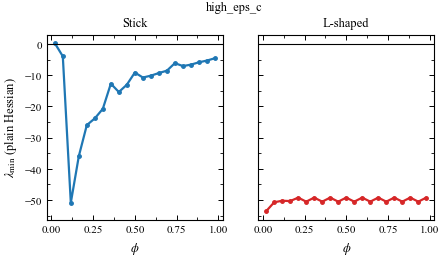

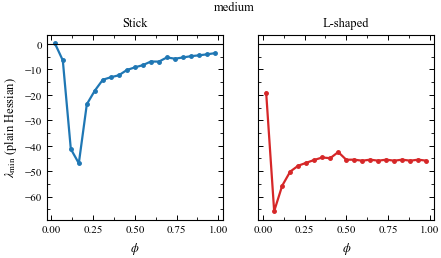

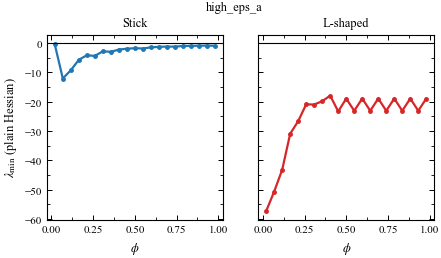

In [8]:
# ---------- Figure 1: lambda_min(phi) for stick and L (per regime) ----------

def _extract_curve(records):
    phis = np.array([r['phi'] for r in records], dtype=float)
    lam_min = np.array([r['evals'][0] for r in records], dtype=float)
    return phis, lam_min

for regime_name, data in analysis_by_regime.items():
    phis_s, lam_s = _extract_curve(data['stick_records'])
    phis_l, lam_l = _extract_curve(data['l_records'])

    fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.4), sharey=True)

    for ax, phis, lam, title, color in [
        (axes[0], phis_s, lam_s, 'Stick', '#1f77b4'),
        (axes[1], phis_l, lam_l, 'L-shaped', '#d62728'),
    ]:
        ax.plot(phis, lam, '-o', ms=2.5, color=color)
        ax.axhline(0.0, color='k', lw=0.8)
        ax.set_title(title)
        ax.set_xlabel(r'$\phi$')
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(which='both', top=True, right=True)

    axes[0].set_ylabel(r'$\lambda_{\min}$ (plain Hessian)')
    fig.suptitle(regime_name, fontsize=9, y=1.02)

    fig.savefig(f'../figures/fig_instability_lambda_scan_{regime_name}.png', dpi=600)
    plt.show()


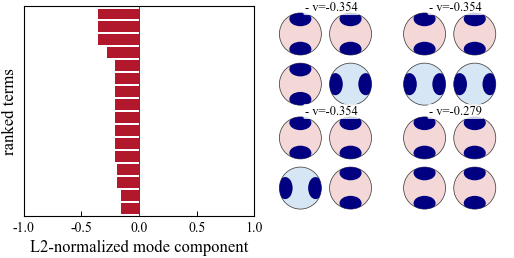

[high_eps_c] stick mode 1: phi_target=0.1000, phi_used=0.1160, lambda=-5.091122e+01, eig_idx=0


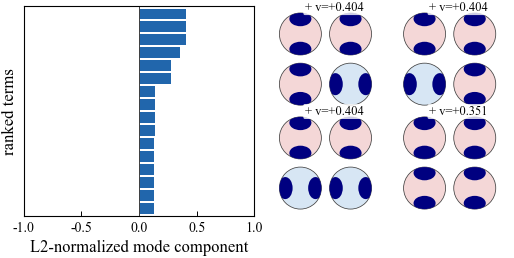

[high_eps_c] stick mode 1: phi_target=0.3000, phi_used=0.3080, lambda=-2.077519e+01, eig_idx=0


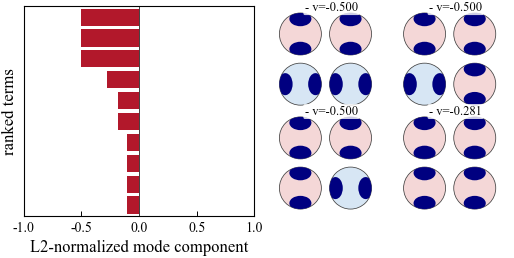

[high_eps_c] stick mode 1: phi_target=0.5000, phi_used=0.5000, lambda=-9.140096e+00, eig_idx=0


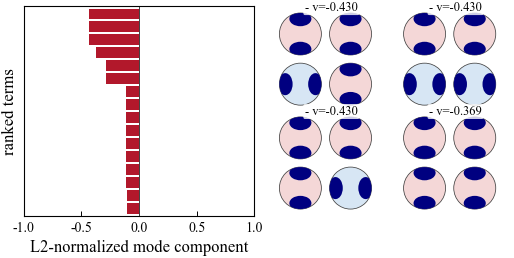

[high_eps_c] stick mode 1: phi_target=0.7000, phi_used=0.6920, lambda=-8.550044e+00, eig_idx=0


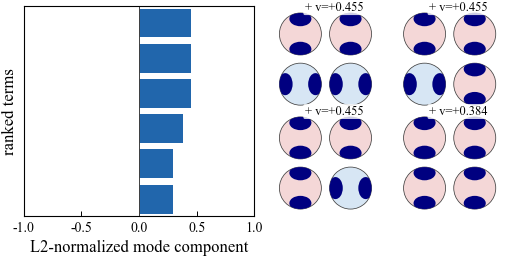

[high_eps_c] stick mode 1: phi_target=0.9000, phi_used=0.8840, lambda=-5.866920e+00, eig_idx=0


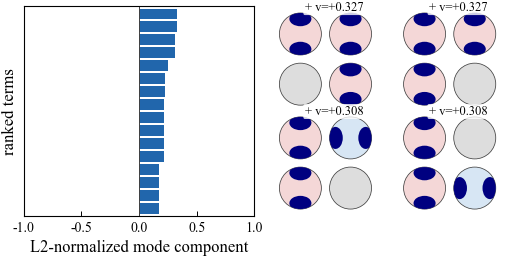

[medium] stick mode 1: phi_target=0.1000, phi_used=0.1160, lambda=-4.127312e+01, eig_idx=0


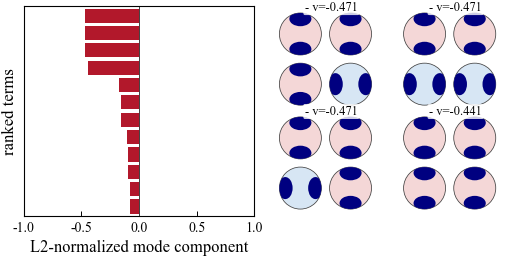

[medium] stick mode 1: phi_target=0.3000, phi_used=0.3080, lambda=-1.408331e+01, eig_idx=0


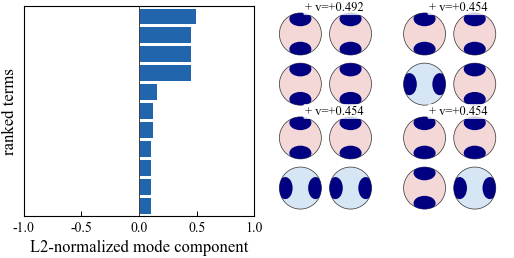

[medium] stick mode 1: phi_target=0.5000, phi_used=0.5000, lambda=-9.226868e+00, eig_idx=0


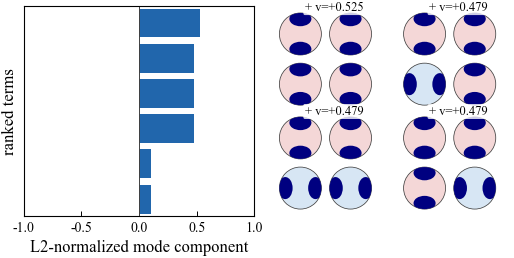

[medium] stick mode 1: phi_target=0.7000, phi_used=0.6920, lambda=-5.325185e+00, eig_idx=0


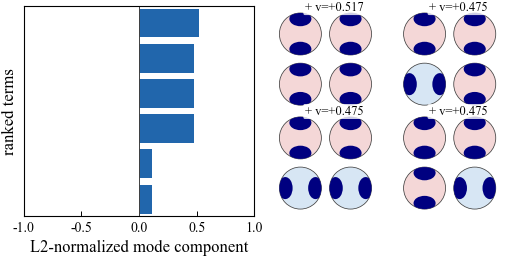

[medium] stick mode 1: phi_target=0.9000, phi_used=0.8840, lambda=-4.508430e+00, eig_idx=0


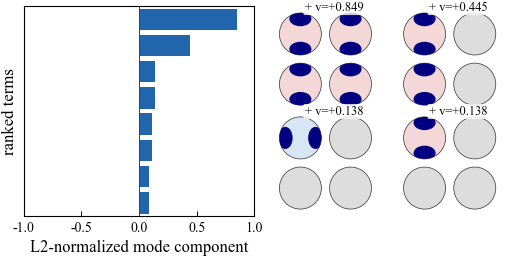

[high_eps_a] stick mode 1: phi_target=0.1000, phi_used=0.1160, lambda=-9.228163e+00, eig_idx=0


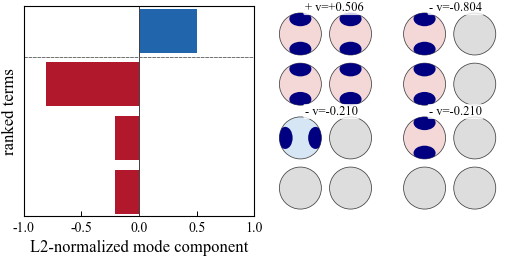

[high_eps_a] stick mode 2: phi_target=0.1000, phi_used=0.1160, lambda=-1.878999e+00, eig_idx=1


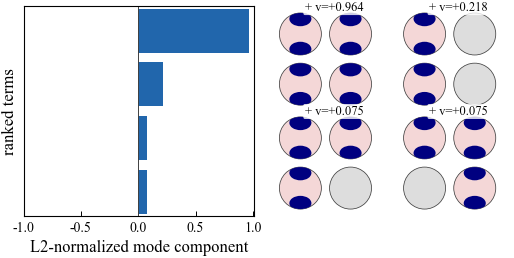

[high_eps_a] stick mode 1: phi_target=0.3000, phi_used=0.3080, lambda=-2.762435e+00, eig_idx=0


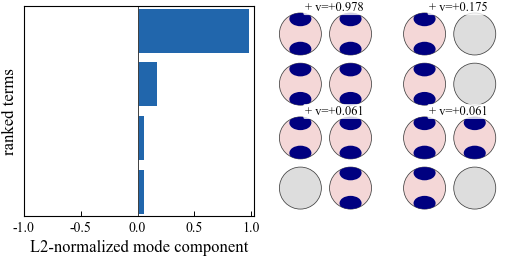

[high_eps_a] stick mode 1: phi_target=0.5000, phi_used=0.5000, lambda=-1.709926e+00, eig_idx=0


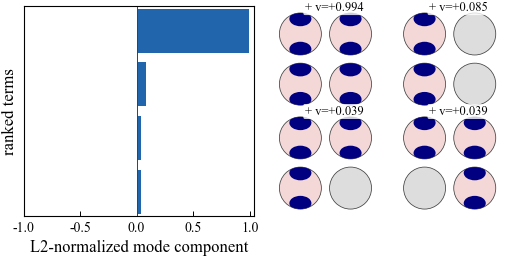

[high_eps_a] stick mode 1: phi_target=0.7000, phi_used=0.6920, lambda=-1.159815e+00, eig_idx=0


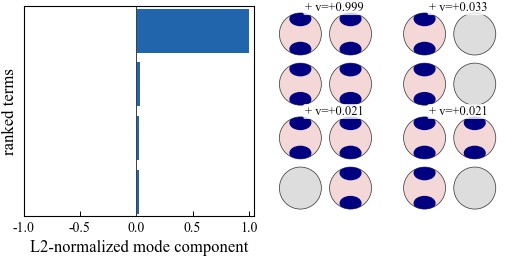

[high_eps_a] stick mode 1: phi_target=0.9000, phi_used=0.8840, lambda=-8.609961e-01, eig_idx=0


In [45]:
# ---------- Figure 2A: stick unstable local motifs at phi=0.1,0.3,0.5,0.7 (both regimes; top 3 unstable modes) ----------

stick_species_facecolors = {
    0: '#f4d7d7',
    1: '#d7e6f4',
    2: '#dddddd',
}

phi_targets_simple = [0.1, 0.3, 0.5, 0.7,0.9]

for regime_name, data in analysis_by_regime.items():
    stick_records = data['stick_records']
    stick_system = data['stick_system']
    stick_cfg = data['stick_cfg']

    for phi_target_simple in phi_targets_simple:
        rec_stick = min(
            stick_records,
            key=lambda r: abs(float(r['phi']) - float(phi_target_simple)),
        )

        mode_ids = top_unstable_mode_ids(rec_stick['evals'], max_modes=6, tol=0.0)
        if not mode_ids:
            print(
                f"[{regime_name}] stick at phi_target={phi_target_simple:.3f}, phi_used={rec_stick['phi']:.3f}: "
                "no unstable modes (all lambda >= 0); skipping."
            )
            continue

        phi_tag = f"phi{int(round(100.0 * float(phi_target_simple))):03d}"

        for rank, mode_idx in enumerate(mode_ids, start=1):
            lam = float(rec_stick['evals'][mode_idx])
            vec_stick = rec_stick['evecs_full'][:, mode_idx]
            vec_stick = vec_stick / (np.linalg.norm(vec_stick) + 1e-30)

            fig, _ = plot_mode_panel(
                stick_system['plaq_configs'],
                stick_system.get('plaq_class_members'),
                stick_system['patches'],
                vec_stick,
                title=(
                    rf"Stick mode {rank} ({regime_name}) at "
                    rf"$\phi_\mathrm{{target}}={phi_target_simple:.2f}$, "
                    rf"$\phi_\mathrm{{used}}={rec_stick['phi']:.3f}$, $\lambda={lam:.3g}$"
                ),
                n_show=min(stick_cfg['top_n'], len(vec_stick)),
                drawer=draw_plaquette_tabbed,
                drawer_kwargs={
                    'patches_species': stick_system['patches'],
                    'species_facecolors': stick_species_facecolors,
                },
                bar_top_k=16,
            )
            fig.savefig(f'../figures/fig_motifs_stick_{regime_name}_{phi_tag}_mode{rank}.png', dpi=600)
            plt.show()
            print(
                f"[{regime_name}] stick mode {rank}: phi_target={phi_target_simple:.4f}, "
                f"phi_used={rec_stick['phi']:.4f}, lambda={lam:+.6e}, eig_idx={mode_idx}"
            )


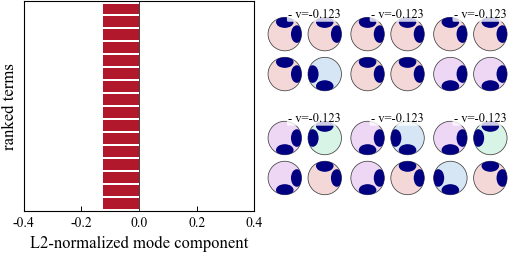

[high_eps_c] L-shaped mode 1: phi_target=0.1000, phi_used=0.1160, lambda=-5.025878e+01, eig_idx=0


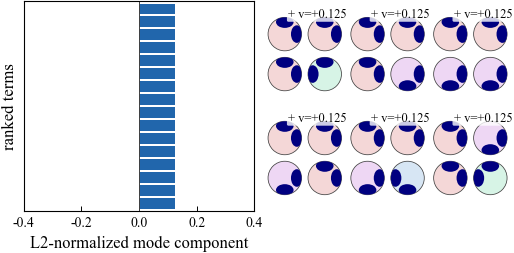

[high_eps_c] L-shaped mode 1: phi_target=0.3000, phi_used=0.3080, lambda=-4.925867e+01, eig_idx=0


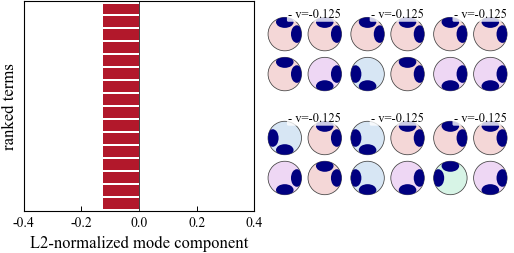

[high_eps_c] L-shaped mode 1: phi_target=0.5000, phi_used=0.5000, lambda=-4.925863e+01, eig_idx=0


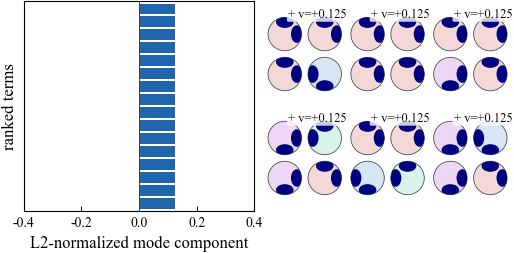

[high_eps_c] L-shaped mode 1: phi_target=0.7000, phi_used=0.6920, lambda=-4.925860e+01, eig_idx=0


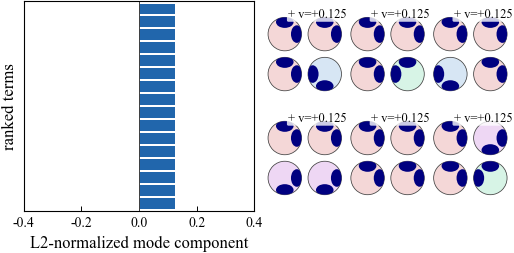

[high_eps_c] L-shaped mode 1: phi_target=0.9000, phi_used=0.8840, lambda=-4.925858e+01, eig_idx=0


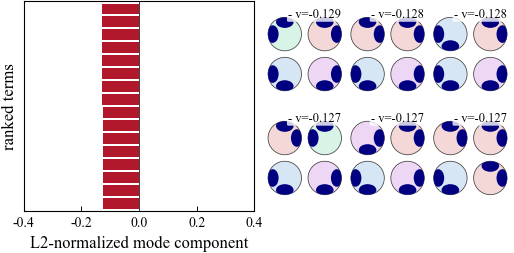

[medium] L-shaped mode 1: phi_target=0.1000, phi_used=0.1160, lambda=-5.569877e+01, eig_idx=0


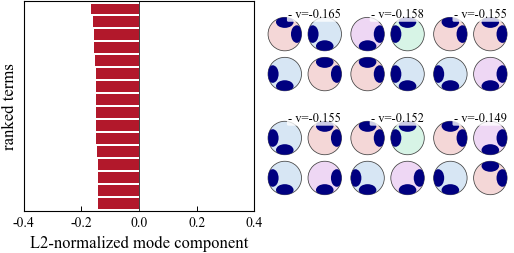

[medium] L-shaped mode 1: phi_target=0.3000, phi_used=0.3080, lambda=-4.558905e+01, eig_idx=0


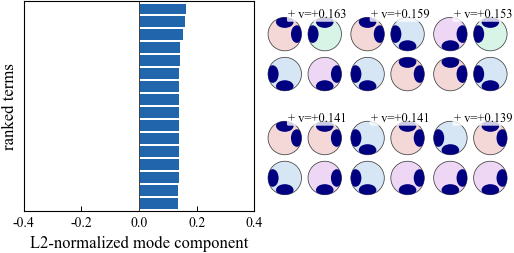

[medium] L-shaped mode 1: phi_target=0.5000, phi_used=0.5000, lambda=-4.548897e+01, eig_idx=0


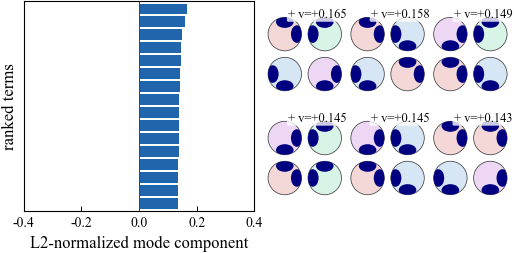

[medium] L-shaped mode 1: phi_target=0.7000, phi_used=0.6920, lambda=-4.586956e+01, eig_idx=0


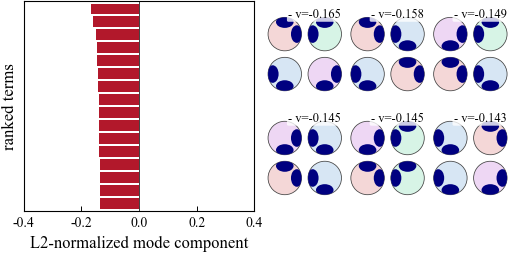

[medium] L-shaped mode 1: phi_target=0.9000, phi_used=0.8840, lambda=-4.586933e+01, eig_idx=0


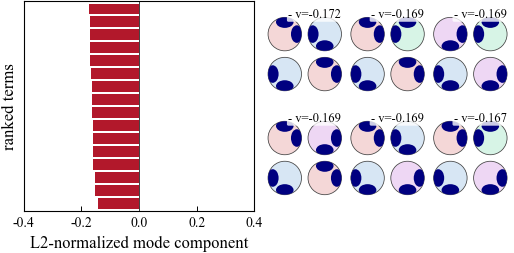

[high_eps_a] L-shaped mode 1: phi_target=0.1000, phi_used=0.1160, lambda=-4.320660e+01, eig_idx=0


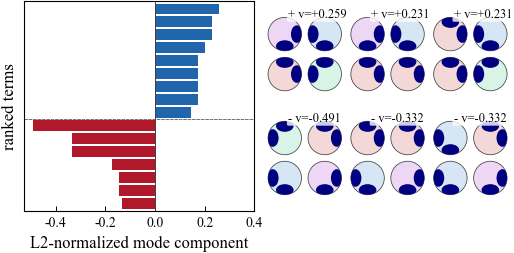

[high_eps_a] L-shaped mode 2: phi_target=0.1000, phi_used=0.1160, lambda=-2.700926e+00, eig_idx=1


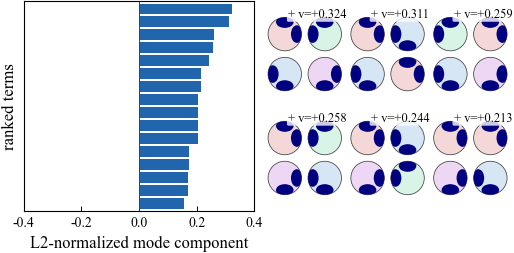

[high_eps_a] L-shaped mode 1: phi_target=0.3000, phi_used=0.3080, lambda=-2.094336e+01, eig_idx=0


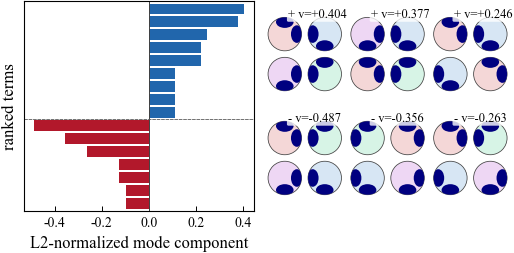

[high_eps_a] L-shaped mode 2: phi_target=0.3000, phi_used=0.3080, lambda=-2.066624e+00, eig_idx=1


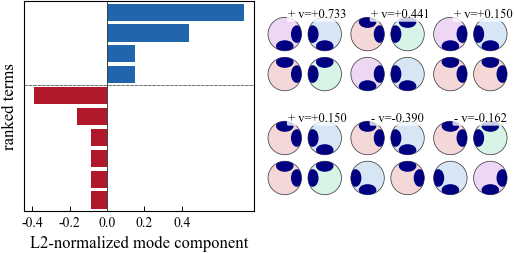

[high_eps_a] L-shaped mode 3: phi_target=0.3000, phi_used=0.3080, lambda=-6.483665e-01, eig_idx=2


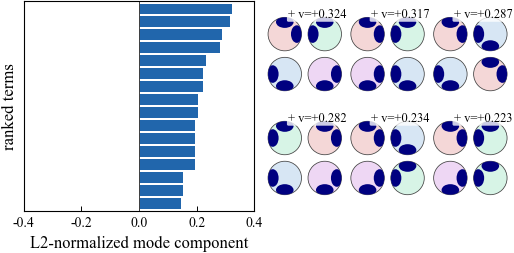

[high_eps_a] L-shaped mode 1: phi_target=0.5000, phi_used=0.5000, lambda=-1.890374e+01, eig_idx=0


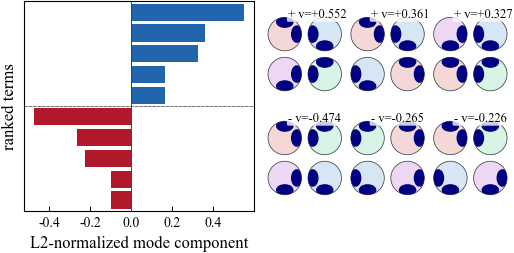

[high_eps_a] L-shaped mode 2: phi_target=0.5000, phi_used=0.5000, lambda=-1.655332e+00, eig_idx=1


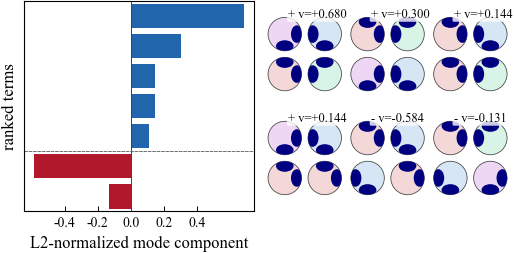

[high_eps_a] L-shaped mode 3: phi_target=0.5000, phi_used=0.5000, lambda=-2.926166e-01, eig_idx=2


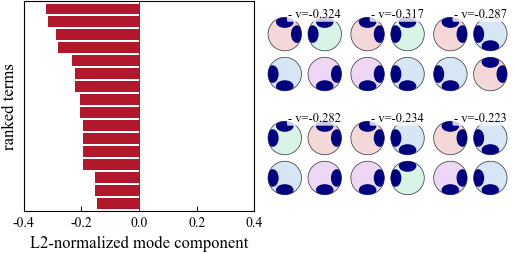

[high_eps_a] L-shaped mode 1: phi_target=0.7000, phi_used=0.6920, lambda=-1.888732e+01, eig_idx=0


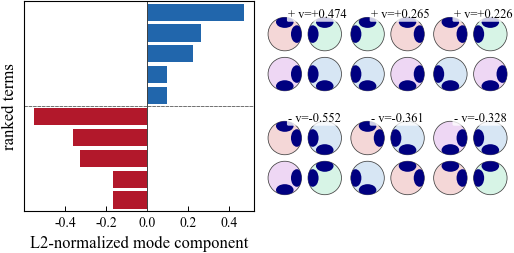

[high_eps_a] L-shaped mode 2: phi_target=0.7000, phi_used=0.6920, lambda=-1.654717e+00, eig_idx=1


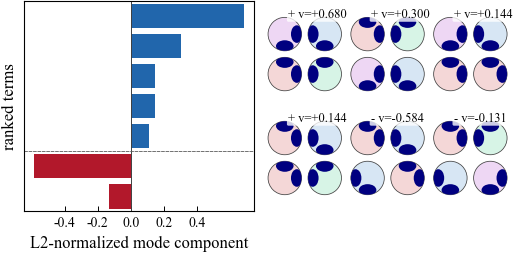

[high_eps_a] L-shaped mode 3: phi_target=0.7000, phi_used=0.6920, lambda=-2.920891e-01, eig_idx=2


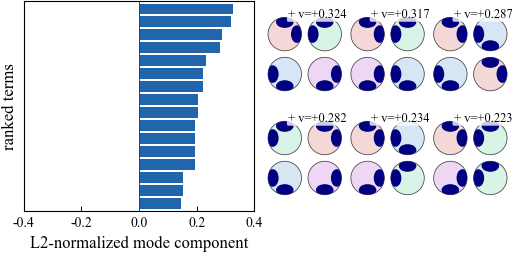

[high_eps_a] L-shaped mode 1: phi_target=0.9000, phi_used=0.8840, lambda=-1.888694e+01, eig_idx=0


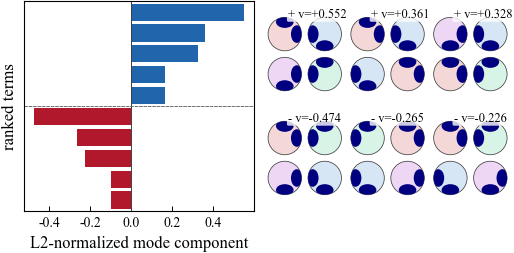

[high_eps_a] L-shaped mode 2: phi_target=0.9000, phi_used=0.8840, lambda=-1.654705e+00, eig_idx=1


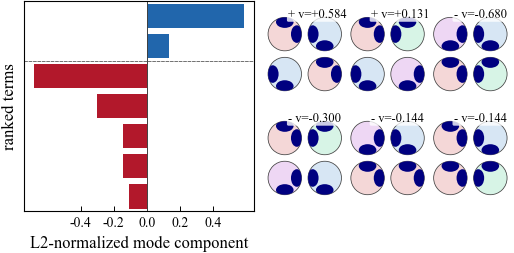

[high_eps_a] L-shaped mode 3: phi_target=0.9000, phi_used=0.8840, lambda=-2.920915e-01, eig_idx=2


In [52]:
# ---------- Figure 2B: L-shape unstable local motifs at phi=0.1,0.3,0.5,0.7 (both regimes; top 3 unstable modes) ----------

l_species_facecolors = {
    0: "#f4d7d7",
    1: "#eed7f4",
    2: "#d7e6f4",
    3: "#d7f4e6",
    4: "#dddddd",
}

phi_targets_simple = [0.1, 0.3, 0.5, 0.7,0.9]

for regime_name, data in analysis_by_regime.items():
    l_records = data["l_records"]
    l_system = data["l_system"]
    l_cfg = data["l_cfg"]

    for phi_target_simple in phi_targets_simple:
        rec_l = min(
            l_records,
            key=lambda r: abs(float(r['phi']) - float(phi_target_simple)),
        )

        mode_ids = top_unstable_mode_ids(rec_l["evals"], max_modes=6, tol=0.0)
        if not mode_ids:
            print(
                f"[{regime_name}] L-shaped at phi_target={phi_target_simple:.3f}, phi_used={rec_l['phi']:.3f}: "
                "no unstable modes (all lambda >= 0); skipping."
            )
            continue

        phi_tag = f"phi{int(round(100.0 * float(phi_target_simple))):03d}"

        for rank, mode_idx in enumerate(mode_ids, start=1):
            lam = float(rec_l["evals"][mode_idx])
            vec_l = rec_l["evecs_full"][:, mode_idx]
            vec_l = vec_l / (np.linalg.norm(vec_l) + 1e-30)

            fig, _ = plot_mode_panel(
                l_system["plaq_configs"],
                l_system.get("plaq_class_members"),
                l_system["patches"],
                vec_l,
                title=(
                    rf"L-shaped mode {rank} ({regime_name}) at "
                    rf"$\phi_\mathrm{{target}}={phi_target_simple:.2f}$, "
                    rf"$\phi_\mathrm{{used}}={rec_l['phi']:.3f}$, $\lambda={lam:.3g}$"
                ),
                n_show=min(l_cfg["top_n"], len(vec_l)),
                drawer=draw_plaquette_tabbed,
                drawer_kwargs={
                    "patches_species": l_system["patches"],
                    "species_facecolors": l_species_facecolors,
                },
                bar_top_k=16,
            )
            fig.savefig(f"../figures/fig_motifs_lshape_{regime_name}_{phi_tag}_mode{rank}.png", dpi=600)
            plt.show()
            print(
                f"[{regime_name}] L-shaped mode {rank}: phi_target={phi_target_simple:.4f}, "
                f"phi_used={rec_l['phi']:.4f}, lambda={lam:+.6e}, eig_idx={mode_idx}"
            )


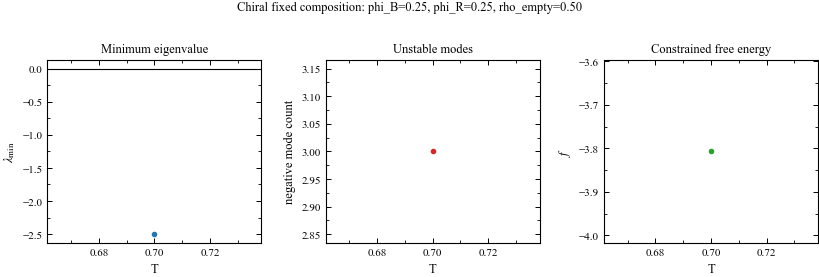

In [11]:
# ---------- Figure 2C: chiral fixed composition summary across temperatures ----------

temps_c = np.array([chiral_results_by_label[label]['cfg']['T'] for label in chiral_labels], dtype=float)
lambda_min_c = np.array([float(chiral_results_by_label[label]['record']['evals'][0]) for label in chiral_labels], dtype=float)
n_negative_c = np.array([int(chiral_results_by_label[label]['record']['n_negative']) for label in chiral_labels], dtype=int)
free_energy_c = np.array([float(chiral_results_by_label[label]['record']['f_phi']) for label in chiral_labels], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(8.4, 2.8), sharex=True)

axes[0].plot(temps_c, lambda_min_c, '-o', ms=3.0, color='#1f77b4')
axes[0].axhline(0.0, color='k', lw=0.8)
axes[0].set_xlabel('T')
axes[0].set_ylabel(r'$\lambda_{\min}$')
axes[0].set_title('Minimum eigenvalue')

axes[1].plot(temps_c, n_negative_c, '-o', ms=3.0, color='#d62728')
axes[1].set_xlabel('T')
axes[1].set_ylabel('negative mode count')
axes[1].set_title('Unstable modes')

axes[2].plot(temps_c, free_energy_c, '-o', ms=3.0, color='#2ca02c')
axes[2].set_xlabel('T')
axes[2].set_ylabel(r'$f$')
axes[2].set_title('Constrained free energy')

for ax in axes:
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which='both', top=True, right=True)

fig.suptitle(
    f"Chiral fixed composition: phi_B={chiral_phi_blue_target:.2f}, "
    f"phi_R={chiral_phi_red_target:.2f}, rho_empty={chiral_rho_empty:.2f}",
    fontsize=9,
    y=1.02,
)
fig.tight_layout()
fig.savefig('../figures/fig_chiral_fixed_phi_blue025_alltemps.png', dpi=600)
plt.show()


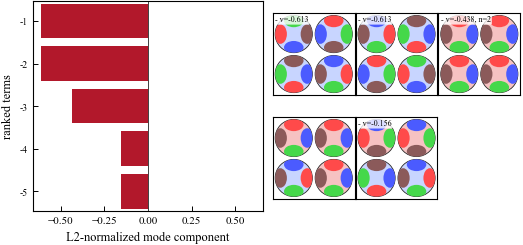

[chiral medium] phi_B_target=0.250, phi_R_target=0.250, mode 1: lambda=-2.502702e+00, eig_idx=0, phi_R=0.2500, phi_B=0.2500, phi_0=0.5000, red_overlap=-0.0429, blue_overlap=-0.0752


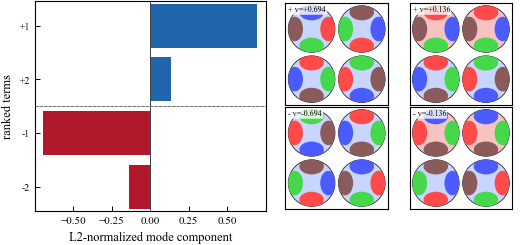

[chiral medium] phi_B_target=0.250, phi_R_target=0.250, mode 2: lambda=-2.009827e+00, eig_idx=1, phi_R=0.2500, phi_B=0.2500, phi_0=0.5000, red_overlap=+0.0000, blue_overlap=+0.0000


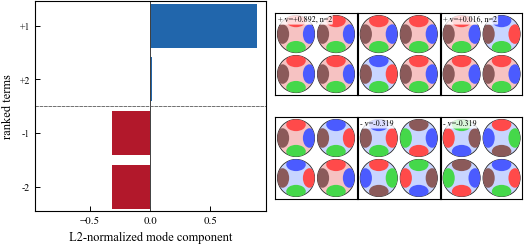

[chiral medium] phi_B_target=0.250, phi_R_target=0.250, mode 3: lambda=-8.055793e-01, eig_idx=2, phi_R=0.2500, phi_B=0.2500, phi_0=0.5000, red_overlap=+0.0480, blue_overlap=-0.0285


In [12]:
# ---------- Figure 3: chiral motifs at fixed phi_blue=0.25 for all temperatures ----------

for chiral_label in chiral_labels:
    data = chiral_results_by_label[chiral_label]
    chiral_cfg = data['cfg']
    rec = data['record']
    mode_ids = rec['negative_mode_ids']

    if not mode_ids:
        print(
            f"[chiral {chiral_label}] phi_B_target={chiral_cfg['phi_blue_target']:.3f}, "
            f"phi_R_target={chiral_cfg['phi_red_target']:.3f}: "
            'no unstable modes (all lambda >= 0); skipping motif figures.'
        )
        continue

    for rank, mode_idx in enumerate(mode_ids, start=1):
        lam = float(rec['evals'][mode_idx])
        vec = np.asarray(data['mode_vectors'][mode_idx], dtype=float)
        vec = vec / (np.linalg.norm(vec) + 1e-30)

        fig, _ = plot_mode_panel(
            data['plaq_configs'],
            data.get('plaq_class_members'),
            data['patches'],
            vec,
            title=(
                rf"Chiral mode {rank} ({chiral_label}, T={chiral_cfg['T']:.1f}), "
                rf"$\phi_\mathrm{{B,target}}={chiral_cfg['phi_blue_target']:.2f}$, "
                rf"$\phi_\mathrm{{R,target}}={chiral_cfg['phi_red_target']:.2f}$, "
                rf"$\lambda={lam:.3g}$"
            ),
            n_show=min(chiral_cfg['top_n'], len(vec)),
            drawer=draw_plaquette_chiral,
            drawer_kwargs={
                'patches': data['patches'],
                'vacancy_species_idx': 8,
            },
            bar_top_k=10,
        )
        fig.savefig(f'../figures/fig_motifs_chiral_fixed_phi_blue025_{chiral_label}_mode{rank}.png', dpi=600)
        plt.show()
        print(
            f"[chiral {chiral_label}] phi_B_target={chiral_cfg['phi_blue_target']:.3f}, "
            f"phi_R_target={chiral_cfg['phi_red_target']:.3f}, mode {rank}: "
            f"lambda={lam:+.6e}, eig_idx={mode_idx}, "
            f"phi_R={rec['red_fraction']:.4f}, phi_B={rec['blue_fraction']:.4f}, phi_0={rec['vacancy_fraction']:.4f}, "
            f"red_overlap={normalized_overlap(vec, data['A_red']):+.4f}, "
            f"blue_overlap={normalized_overlap(vec, data['A_blue']):+.4f}"
        )


In [13]:
# ---------- Optional: concise text table for manuscript values by regime and fixed-phi_blue chiral cases ----------

def summarize_record_set(name, records):
    lam = np.array([r['evals'][0] for r in records], dtype=float)
    phi = np.array([r['phi'] for r in records], dtype=float)
    i = int(np.argmin(lam))
    return {
        'system': name,
        'phi_at_min': float(phi[i]),
        'lambda_min': float(lam[i]),
    }

for regime_name, data in analysis_by_regime.items():
    print(f'\n=== {regime_name} ===')
    summary = [
        summarize_record_set('stick', data['stick_records']),
        summarize_record_set('lshape', data['l_records']),
    ]
    for row in summary:
        print(row)

print(
    f"\n=== chiral fixed composition | phi_B={chiral_phi_blue_target:.3f}, "
    f"phi_R={chiral_phi_red_target:.3f}, rho_empty={chiral_rho_empty:.3f} ==="
)
for chiral_label in chiral_labels:
    data = chiral_results_by_label[chiral_label]
    chiral_cfg = data['cfg']
    rec = data['record']

    print(
        f"[{chiral_label}] T={chiral_cfg['T']:.1f} "
        f"phi_R={rec['red_fraction']:.4f} phi_B={rec['blue_fraction']:.4f} phi_0={rec['vacancy_fraction']:.4f} "
        f"residual={rec['residual']:.2e} n_negative={rec['n_negative']} "
        f"lambda_min={float(rec['evals'][0]):+.6e}"
    )

    if not rec['negative_mode_ids']:
        print('  no negative modes found')
        continue

    for rank, mode_idx in enumerate(rec['negative_mode_ids'], start=1):
        vec = np.asarray(data['mode_vectors'][mode_idx], dtype=float)
        vec = vec / (np.linalg.norm(vec) + 1e-30)
        rows = describe_mode_components(vec, data['plaq_configs'], top_n=3)
        raw_str = '; '.join(
            f"cfg={row['cfg']}, v={row['value']:+.2g}"
            for row in rows
        )
        print(
            f"  mode {rank} eig_idx={mode_idx} lambda={float(rec['evals'][mode_idx]):+.6e} "
            f"red_overlap={normalized_overlap(vec, data['A_red']):+.4f} "
            f"blue_overlap={normalized_overlap(vec, data['A_blue']):+.4f}"
        )
        print(f"    raw : {raw_str}")



=== high_eps_c ===
{'system': 'stick', 'phi_at_min': 0.116, 'lambda_min': -50.91122347194682}
{'system': 'lshape', 'phi_at_min': 0.02, 'lambda_min': -53.60945606816189}

=== medium ===
{'system': 'stick', 'phi_at_min': 0.164, 'lambda_min': -46.89681900642131}
{'system': 'lshape', 'phi_at_min': 0.068, 'lambda_min': -65.69578852935967}

=== high_eps_a ===
{'system': 'stick', 'phi_at_min': 0.068, 'lambda_min': -12.050096645351156}
{'system': 'lshape', 'phi_at_min': 0.02, 'lambda_min': -57.30928062352262}

=== chiral fixed composition | phi_B=0.250, phi_R=0.250, rho_empty=0.500 ===
[medium] T=0.7 phi_R=0.2500 phi_B=0.2500 phi_0=0.5000 residual=9.53e-11 n_negative=3 lambda_min=-2.502702e+00
  mode 1 eig_idx=0 lambda=-2.502702e+00 red_overlap=-0.0429 blue_overlap=-0.0752
    raw : cfg=(6, 5, 7, 4), v=-0.61; cfg=(4, 7, 5, 6), v=-0.61; cfg=(0, 0, 0, 0), v=-0.44
  mode 2 eig_idx=1 lambda=-2.009827e+00 red_overlap=+0.0000 blue_overlap=+0.0000
    raw : cfg=(4, 7, 5, 6), v=+0.69; cfg=(6, 5, 7, 4